In [1]:
print("--- Analisi Competitori---")

--- Analisi Competitori---


In [12]:
!pip install kaggle


   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ---------------------------------------- 0/3 [kagglesdk]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   ------------- -------------------------- 1/3 [jupytext]
   -------------------------- ------------- 2/3 [kaggle]
   -------------------------- ------------- 2/3 [kaggle]
   ---------------------------------------- 3/3 [kaggle]



In [14]:
## importiamo i dati
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os


In [15]:
## url dataset
url = "https://www.kaggle.com/datasets/rkiattisak/shoe-prices-dataset"


In [18]:
## download dataset
!kaggle datasets download -d rkiattisak/shoe-prices-dataset
## estrazione zip
with zipfile.ZipFile("shoe-prices-dataset.zip", "r") as zip_ref:zip_ref.extractall()

Dataset URL: https://www.kaggle.com/datasets/rkiattisak/shoe-prices-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
shoe-prices-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
## CONTROLLIAMO I FILE
print (os.listdir())

['.anaconda', '.conda', '.condarc', '.continuum', '.gitconfig', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kaggle', '.matplotlib', '.ms-ad', '.virtual_documents', '.vscode', '3D Objects', 'anaconda3', 'anaconda_projects', 'AppData', 'Contacts', 'Cookies', 'Dati applicazioni', 'Documenti', 'Documents', 'Downloads', 'Esame fine modulo sql completo.sql', 'Esame fine modulo sql.sql', 'EsameFinalePython.ipynb', 'esercizi join.sql', 'Esercizio adventur.sql', 'Favorites', 'Gino e Romano.pdf', 'IMAGINE ERR.png', 'Impostazioni locali', 'lezione 2', 'lezione WK92.ipynb', 'lezione02.py', 'lezione2.ipynb', 'Links', 'Menu Avvio', 'MicrosoftEdgeBackups', 'MODEL EER.mwb', 'Modelli', 'Music', 'NCH Software Suite', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.0.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.1.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea-11ee-a54d-000d3a94eaa1}.TxR.2.regtrans-ms', 'NTUSER.DAT{2ad838bb-efea

In [21]:
## Carichiamo il csv
df =pd.read_csv("shoe prices.csv")

In [22]:
## visualizziamo i dati
df.head()

,Brand,Model,Type,Gender,Size,Color,Material,Price (USD)
0,Nike,Air Jordan 1,Basketball,Men,US 10,Red/Black,Leather,$170.00
1,Adidas,Ultra Boost 21,Running,Men,US 9.5,Black,Primeknit,$180.00
2,Reebok,Classic Leather,Casual,Men,US 11,White,Leather,$75.00
3,Converse,Chuck Taylor,Casual,Women,US 8,Navy,Canvas,$55.00
4,Puma,Future Rider,Lifestyle,Women,US 7.5,Pink,Mesh,$80.00


In [ ]:
## Pulizia dei prezzi e Definizione del "nostro Brand". in questa cella convertiamo i prezzi in numeri e impostiamo,
## Nike come il nostro brand di riferimento 
## per differenziarlo dal competitor: Addidas e Puma

In [41]:
## Rimuoviamo il simbolo del dollaro e convertiamo la colmana in numeri decimali (float)
## 1. Pulizia della colonna prezzi
df['Price (USD)'] = df['Price (USD)'].astype(str).str.replace('$', '', regex=False).str.strip()
df['Price (USD)'] = pd.to_numeric(df['Price (USD)'], errors='coerce')
df = df.dropna(subset=['Price (USD)'])

## 2. Pulizia del testo (Brand e Categorie)
df['Brand'] = df['Brand'].astype(str).str.strip()
df['Type'] = df['Type'].astype(str).str.strip().str.title()

## 3. FILTRO A 3 BRAND: Isoliamo Nike, Adidas e Puma
df_tre_brand = df[df['Brand'].isin(['Nike', 'Adidas', 'Puma'])].copy()

## 4. Selezioniamo le macro-categorie principali in comune
macro_tipologie = ['Basketball', 'Casual', 'Running']
df_analisi = df_tre_brand[df_tre_brand['Type'].isin(macro_tipologie)]

print("Filtro completato! Brand inclusi nell'analisi:", df_analisi['Brand'].unique())



Filtro completato! Brand inclusi nell'analisi: ['Nike' 'Adidas' 'Puma']


In [ ]:
## 2) Analisi Comparativa Statistica 
## adesso che i prezzi sono numerici, usiamo .groupby () per calcolare in un colpo solo il numero dei modelli, il prezzo minimo
## massimo e la media per ogni tipologia di scarpa, dividendo il nostro brand dai concorrenti

In [50]:

## Aggregazione statistica richiesta dalla traccia
# Calcoliamo il numero dei modelli, prezzi minimi, massimi e medi per i 3 brand
report_tre_brand = df_analisi.groupby(['Brand', 'Type']).agg(
    Numero_Modelli=('Price (USD)', 'count'),
    Prezzo_Minimo=('Price (USD)', 'min'),
    Prezzo_Massimo=('Price (USD)', 'max'),
    Prezzo_Medio=('Price (USD)', 'mean')
).reset_index().round(2)

report_tre_brand



,Brand,Type,Numero_Modelli,Prezzo_Minimo,Prezzo_Massimo,Prezzo_Medio
0,Adidas,Basketball,3,80.0,130.0,113.33
1,Adidas,Casual,22,80.0,220.0,102.27
2,Adidas,Running,30,120.0,180.0,163.67
3,Nike,Basketball,15,90.0,170.0,101.33
4,Nike,Casual,40,85.0,120.0,92.88
5,Nike,Running,58,100.0,250.0,150.52
6,Puma,Basketball,25,80.0,130.0,124.80
7,Puma,Casual,11,65.0,80.0,66.36
8,Puma,Running,39,80.0,140.0,99.23


In [84]:
## Raggruppiamo per Brand e per Tipologia di calzatura, calcolando i KPI richiesti
report_ceo = df_analisi.groupby(['Brand', 'Type']).agg(
    Numero_Modelli=('Price (USD)', 'count'),
    Prezzo_Minimo=('Price (USD)', 'min'),
    Prezzo_Massimo=('Price (USD)', 'max'),
    Prezzo_Medio=('Price (USD)', 'mean')
).reset_index()

# Arrotondiamo i prezzi a due decimalmi 
report_ceo = report_ceo.round(2)

# Mostriamo la nuova tabella dei KPI a schermo
report_ceo



,Brand,Type,Numero_Modelli,Prezzo_Minimo,Prezzo_Massimo,Prezzo_Medio
0,Adidas,Basketball,3,80.0,130.0,113.33
1,Adidas,Casual,22,80.0,220.0,102.27
2,Adidas,Running,30,120.0,180.0,163.67
3,Nike,Basketball,15,90.0,170.0,101.33
4,Nike,Casual,40,85.0,120.0,92.88
5,Nike,Running,58,100.0,250.0,150.52
6,Puma,Basketball,25,80.0,130.0,124.80
7,Puma,Casual,11,65.0,80.0,66.36
8,Puma,Running,39,80.0,140.0,99.23


In [85]:
## GRAFICI

In [86]:
print ("---GRAFICO 1: Confronto dei prezzi Medi per Categorie Principali---")

---GRAFICO 1: Confronto dei prezzi Medi per Categorie Principali---


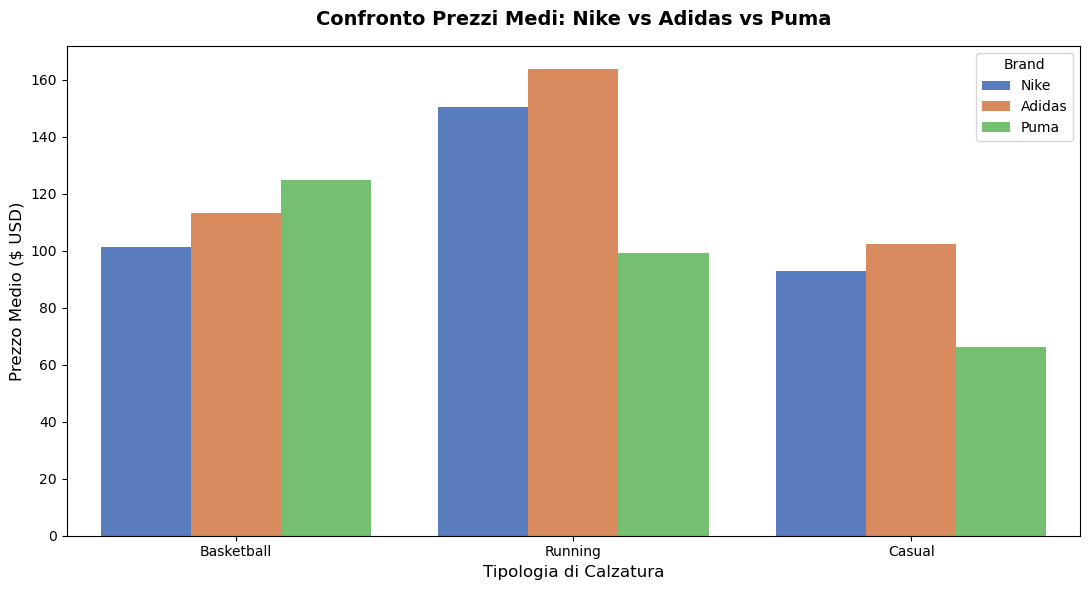

In [87]:
## Selezioniamo le categorie principali con un numero significativo di modelli per un'analisi pulita
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))
sns.barplot(
    data=df_analisi, 
    x='Type', 
    y='Price (USD)', 
    hue='Brand', 
    palette='muted', # Palette di colori pulita e professionale per 3 elementi
    errorbar=None
)
plt.title('Confronto Prezzi Medi: Nike vs Adidas vs Puma', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipologia di Calzatura', fontsize=12)
plt.ylabel('Prezzo Medio ($ USD)', fontsize=12)
plt.legend(title='Brand')
plt.tight_layout()
plt.savefig('confronto_prezzi_3_brand.png', dpi=300)
plt.show()


In [88]:
print("--- Comento grafico 1---")

commento_1 ="""
Analisi di Pricing Comparativa (Nike vs Adidas vs Puma):Il grafico evidenzia tre posizionamenti strategici distinti per categoria.
Nel Running, Adidas e Nike confermano il loro status premium con i prezzi medi più alti (rispettivamente >160$ e ~150$),distaccando nettamente 
Puma (~100$). Situazione inversa nel Basketball,dove Puma si posiziona come brand di fascia più alta (~125$) rispetto a Nike,che mantiene 
un prezzo più entry-level (poco sopra i 100$).Nel segmento Casual, il mercato è guidato dai prezzi di Adidas (~100$) e Nike (~95$),
mentre Puma si conferma la scelta più accessibile (sotto i 70$)
"""

print(commento_1)

--- Comento grafico 1---

Analisi di Pricing Comparativa (Nike vs Adidas vs Puma):Il grafico evidenzia tre posizionamenti strategici distinti per categoria.
Nel Running, Adidas e Nike confermano il loro status premium con i prezzi medi più alti (rispettivamente >160$ e ~150$),distaccando nettamente 
Puma (~100$). Situazione inversa nel Basketball,dove Puma si posiziona come brand di fascia più alta (~125$) rispetto a Nike,che mantiene 
un prezzo più entry-level (poco sopra i 100$).Nel segmento Casual, il mercato è guidato dai prezzi di Adidas (~100$) e Nike (~95$),
mentre Puma si conferma la scelta più accessibile (sotto i 70$)



In [89]:
## Grafico 2 
print("---Grafica 2: Quota di Assortimento dei tre Brand---")

---Grafica 2: Quota di Assortimento dei tre Brand---


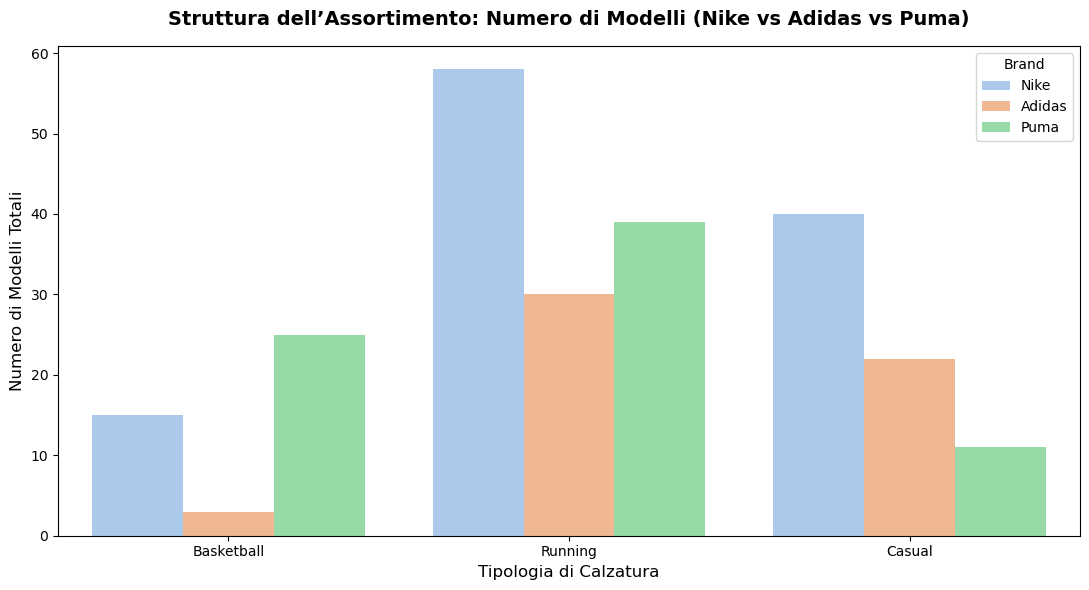

In [90]:
plt.figure(figsize=(11, 6))
sns.countplot(
    data=df_analisi, 
    x='Type', 
    hue='Brand', 
    palette='pastel'
)
plt.title('Struttura dell’Assortimento: Numero di Modelli (Nike vs Adidas vs Puma)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipologia di Calzatura', fontsize=12)
plt.ylabel('Numero di Modelli Totali', fontsize=12)
plt.legend(title='Brand')
plt.tight_layout()
plt.savefig('volume_3_brand.png', dpi=300)
plt.show()


In [91]:
print("---Commento Grafico 2 ---")

---Commento Grafico 2 ---


In [92]:
commento_2 ="""
Il grafico evidenzia le priorità commerciali dei tre brand in base al volume di modelli offerti.
Nike domina nettamente l'assortimento sia nel Running (oltre 55 modelli) che nel Casual (circa 38 modelli),
puntando su una forte penetrazione e diversificazione dell'offerta. Puma si focalizza strategicamente sulle nicchie,
guidando il segmento Basketball con 25 modelli (rispetto ai pochissimi di Adidas) e mantenendo una solida presenza nel Running.
Adidas mostra un catalogo più snello e concentrato in tutte e tre le categorie, prediligendo una strategia basata su meno referenze
ma a valore più alto (come visto nel grafico dei prezzi).
"""
print(commento_2)


Il grafico evidenzia le priorità commerciali dei tre brand in base al volume di modelli offerti.
Nike domina nettamente l'assortimento sia nel Running (oltre 55 modelli) che nel Casual (circa 38 modelli),
puntando su una forte penetrazione e diversificazione dell'offerta. Puma si focalizza strategicamente sulle nicchie,
guidando il segmento Basketball con 25 modelli (rispetto ai pochissimi di Adidas) e mantenendo una solida presenza nel Running.
Adidas mostra un catalogo più snello e concentrato in tutte e tre le categorie, prediligendo una strategia basata su meno referenze
ma a valore più alto (come visto nel grafico dei prezzi).



In [93]:
## Analisi delle varianti di prodotto: Conteggio dei Colori e delle Taglie uniche per ciascun Brand
report_varianti_catalogo = df_analisi.groupby(['Brand', 'Type']).agg(
    Varianti_Colore_Uniche=('Color', 'nunique'),
    Estensione_Taglie_Uniche=('Size', 'nunique')
).reset_index()

print("--- ANALISI COMPLESSITÀ E VARIANTI DI CATALOGO ---")
report_varianti_catalogo


--- ANALISI COMPLESSITÀ E VARIANTI DI CATALOGO ---


,Brand,Type,Varianti_Colore_Uniche,Estensione_Taglie_Uniche
0,Adidas,Basketball,2,2
1,Adidas,Casual,9,9
2,Adidas,Running,9,11
3,Nike,Basketball,4,3
4,Nike,Casual,8,9
5,Nike,Running,13,12
6,Puma,Basketball,9,10
7,Puma,Casual,6,6
8,Puma,Running,11,10


In [94]:
Commento_analisi_complessità = """
 La tabella delle varianti conferma l'imbattibile leadership competitiva di Nike nei segmenti Running e Casual, 
 dove la massima varietà di colori e taglie satura il mercato e schiaccia Adidas.
 Tuttavia, i dati accendono un campanello d'allarme nel Basketball:
 limitando l'offerta a pochissime varianti (4 colori e 3 taglie),stiamo lasciando scoperto il fianco a Puma,
 che ha trasformato questa nicchia nella sua categoria bandiera dominando l'assortimento.
 """
print (Commento_analisi_complessità)


 La tabella delle varianti conferma l'imbattibile leadership competitiva di Nike nei segmenti Running e Casual, 
 dove la massima varietà di colori e taglie satura il mercato e schiaccia Adidas.
 Tuttavia, i dati accendono un campanello d'allarme nel Basketball:
 limitando l'offerta a pochissime varianti (4 colori e 3 taglie),stiamo lasciando scoperto il fianco a Puma,
 che ha trasformato questa nicchia nella sua categoria bandiera dominando l'assortimento.
 


In [95]:
# Troviamo il modello più costoso per ciascun brand
modelli_top_price = df_analisi.loc[df_analisi.groupby('Brand')['Price (USD)'].idxmax()]
modelli_top_price[['Brand', 'Type', 'Color', 'Size', 'Price (USD)']]

,Brand,Type,Color,Size,Price (USD)
795,Adidas,Casual,Cream White,US 11,220.0
555,Nike,Running,Black/White,US 10,250.0
156,Puma,Running,Black/Yellow,US 9.5,140.0


In [96]:
Commento_modello_costoso="""
L'analisi dei prezzi massimi evidenzia il tetto del posizionamento d'immagine dei tre marchi.
Nike guida il mercato presidiando la fascia premium più alta con un modello da 250$ nel Running, 
confermando la massima forza del brand power iper-tecnico. Al contrario, Adidas concentra il suo picco nel segmento Casual (220$),
puntando sulla marginalità della moda urbana, mentre Puma adotta una linea molto più conservativa fermando il suo modello top a 140$ nel Running,
rinunciando ai picchi estremi per mantenere una maggiore accessibilità complessiva.
"""
print(Commento_modello_costoso)


L'analisi dei prezzi massimi evidenzia il tetto del posizionamento d'immagine dei tre marchi.
Nike guida il mercato presidiando la fascia premium più alta con un modello da 250$ nel Running, 
confermando la massima forza del brand power iper-tecnico. Al contrario, Adidas concentra il suo picco nel segmento Casual (220$),
puntando sulla marginalità della moda urbana, mentre Puma adotta una linea molto più conservativa fermando il suo modello top a 140$ nel Running,
rinunciando ai picchi estremi per mantenere una maggiore accessibilità complessiva.



In [97]:
# Calcoliamo l'ampiezza della gamma di prezzo per ogni brand
forbice_prezzi = df_analisi.groupby('Brand')['Price (USD)'].agg(lambda x: x.max() - x.min()).reset_index()
forbice_prezzi.columns = ['Brand', 'Ampiezza_Gamma_Prezzo']
forbice_prezzi

,Brand,Ampiezza_Gamma_Prezzo
0,Adidas,140.0
1,Nike,165.0
2,Puma,75.0


In [98]:
Commento_Analisi_ampiezza = """
L'analisi della forbice evidenzia strategie di flessibilità commerciale profondamente diverse: 
Nike mostra la maggiore escursione di mercato (165$), confermando una strategia democratica e capillare che le permette di presidiare 
contemporaneamente le fasce d'ingresso economiche e i picchi del lusso tecnico. Adidas segue a breve distanza con un'escursione di 140$
focalizzata a proteggere il valore del brand, mentre Puma adotta una linea estremamente compressa con una forbice di soli 75$,
concentrando l'offerta in un range di prezzo ridotto che ne limita la capacità di attrarre clienti alto-spendenti al di fuori delle proprie nicchie.
"""
print(Commento_Analisi_ampiezza)


L'analisi della forbice evidenzia strategie di flessibilità commerciale profondamente diverse: 
Nike mostra la maggiore escursione di mercato (165$), confermando una strategia democratica e capillare che le permette di presidiare 
contemporaneamente le fasce d'ingresso economiche e i picchi del lusso tecnico. Adidas segue a breve distanza con un'escursione di 140$
focalizzata a proteggere il valore del brand, mentre Puma adotta una linea estremamente compressa con una forbice di soli 75$,
concentrando l'offerta in un range di prezzo ridotto che ne limita la capacità di attrarre clienti alto-spendenti al di fuori delle proprie nicchie.



In [99]:
# Quanti modelli sono sotto i 100$ (Fascia Core/Entry) e quanti sopra i 150$ (Fascia Premium)?
df_analisi['Fascia_Prezzo'] = df_analisi['Price (USD)'].apply(lambda x: 'Fascia Bassa (<100$)'if x < 100 else ('Fascia Alta (>150$)' if x > 150 else 'Fascia Media (100-150$)'))
report_fasce = df_analisi.groupby(['Brand', 'Fascia_Prezzo']).size().unstack(fill_value=0)
report_fasce


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_18248\2238299275.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analisi['Fascia_Prezzo'] = df_analisi['Price (USD)'].apply(lambda x: 'Fascia Bassa (<100$)'if x < 100 else ('Fascia Alta (>150$)' if x > 150 else 'Fascia Media (100-150$)'))


Fascia_Prezzo,Fascia Alta (>150$),Fascia Bassa (<100$),Fascia Media (100-150$)
Brand,,,
Adidas,20,16,19
Nike,33,40,40
Puma,0,34,41


In [106]:
print("---sintesi e Raccomandazioni---")

---sintesi e Raccomandazioni---


In [107]:
Commento_modelli="""
L'analisi evidenzia l'assoluto dominio distributivo di Nike, che presidia capillarmente il mercato con ben 113 modelli complessivi, 
mantenendo un perfetto bilanciamento strategico tra i volumi commerciali della Fascia Bassa (40 modelli) 
e la marginalità della Fascia Alta (33 modelli). Al contrario, Adidas mostra un catalogo più ridotto (66 modelli) 
e fortemente polarizzato verso il segmento Premium (50 modelli distribuiti tra fascia media e alta a fronte di soli 16 bassi),
confermando una strategia mirata a proteggere il valore del brand. Infine, Puma si posiziona nettamente come marchio di volumi e di massa:
concentra tutta la sua forza competitiva tra le fasce medie e basse (75 modelli totali) azzerando completamente la sua presenza sopra i 150 dollari,
scelta che ne conferma un posizionamento decisamente più accessibile e focalizzato sull'alta rotazione.
"""
print(Commento_modelli)


L'analisi evidenzia l'assoluto dominio distributivo di Nike, che presidia capillarmente il mercato con ben 113 modelli complessivi, 
mantenendo un perfetto bilanciamento strategico tra i volumi commerciali della Fascia Bassa (40 modelli) 
e la marginalità della Fascia Alta (33 modelli). Al contrario, Adidas mostra un catalogo più ridotto (66 modelli) 
e fortemente polarizzato verso il segmento Premium (50 modelli distribuiti tra fascia media e alta a fronte di soli 16 bassi),
confermando una strategia mirata a proteggere il valore del brand. Infine, Puma si posiziona nettamente come marchio di volumi e di massa:
concentra tutta la sua forza competitiva tra le fasce medie e basse (75 modelli totali) azzerando completamente la sua presenza sopra i 150 dollari,
scelta che ne conferma un posizionamento decisamente più accessibile e focalizzato sull'alta rotazione.



In [108]:
Commento_Raccomandazioni="""
Per difendere la leadership, Nike deve attuare una strategia duale: presidiare la Fascia Core potenziando l'offerta Casual sotto i 100$
per bloccare l'avanzata di Puma (che domina i volumi medio-bassi con 75 modelli ed erode la base clienti più giovane);
colmare il gap nel Basketball, dove l'assortimento limitato di Nike cede il passo all'iper-personalizzazione di Puma (9 colori e 10 taglie uniche); 
e infine razionalizzare il catalogo complessivo di 113 modelli,
tagliando i doppioni a bassa rotazione per ridurre la complessità logistica e ottimizzare i costi operativi sull'esempio dei competitor più snelli.
"""
print(Commento_Raccomandazioni)


Per difendere la leadership, Nike deve attuare una strategia duale: presidiare la Fascia Core potenziando l'offerta Casual sotto i 100$
per bloccare l'avanzata di Puma (che domina i volumi medio-bassi con 75 modelli ed erode la base clienti più giovane);
colmare il gap nel Basketball, dove l'assortimento limitato di Nike cede il passo all'iper-personalizzazione di Puma (9 colori e 10 taglie uniche); 
e infine razionalizzare il catalogo complessivo di 113 modelli,
tagliando i doppioni a bassa rotazione per ridurre la complessità logistica e ottimizzare i costi operativi sull'esempio dei competitor più snelli.

